Loading data...
Calculating metrics...
AUTOMATED GRADING MODEL EVALUATION REPORT

DATASET OVERVIEW
----------------------------------------
Total submissions: 60
Number of questions: 5
Number of students: 12
Expert grade range: 0.0 - 10.0
Model grade range: 0.0 - 9.0

STATISTICAL PERFORMANCE METRICS
----------------------------------------
Mean Absolute Error (MAE):     0.467
Root Mean Square Error (RMSE): 0.775
R-squared (R²):                0.932
Pearson Correlation:           0.968 (p = 1.870e-36)
Spearman Correlation:          0.947 (p = 2.203e-30)

AGREEMENT ANALYSIS
----------------------------------------
Exact Agreement:               60.0%
Agreement within ±1 point:     93.3%
Agreement within ±2 points:    100.0%
Classification Accuracy:       95.0%

BIAS ANALYSIS
----------------------------------------
Mean Bias (Model - Expert):    +0.000
Standard Deviation of Bias:    0.775
Bias Interpretation:           negligible underestimation

PERFORMANCE BY QUESTION
-----------------

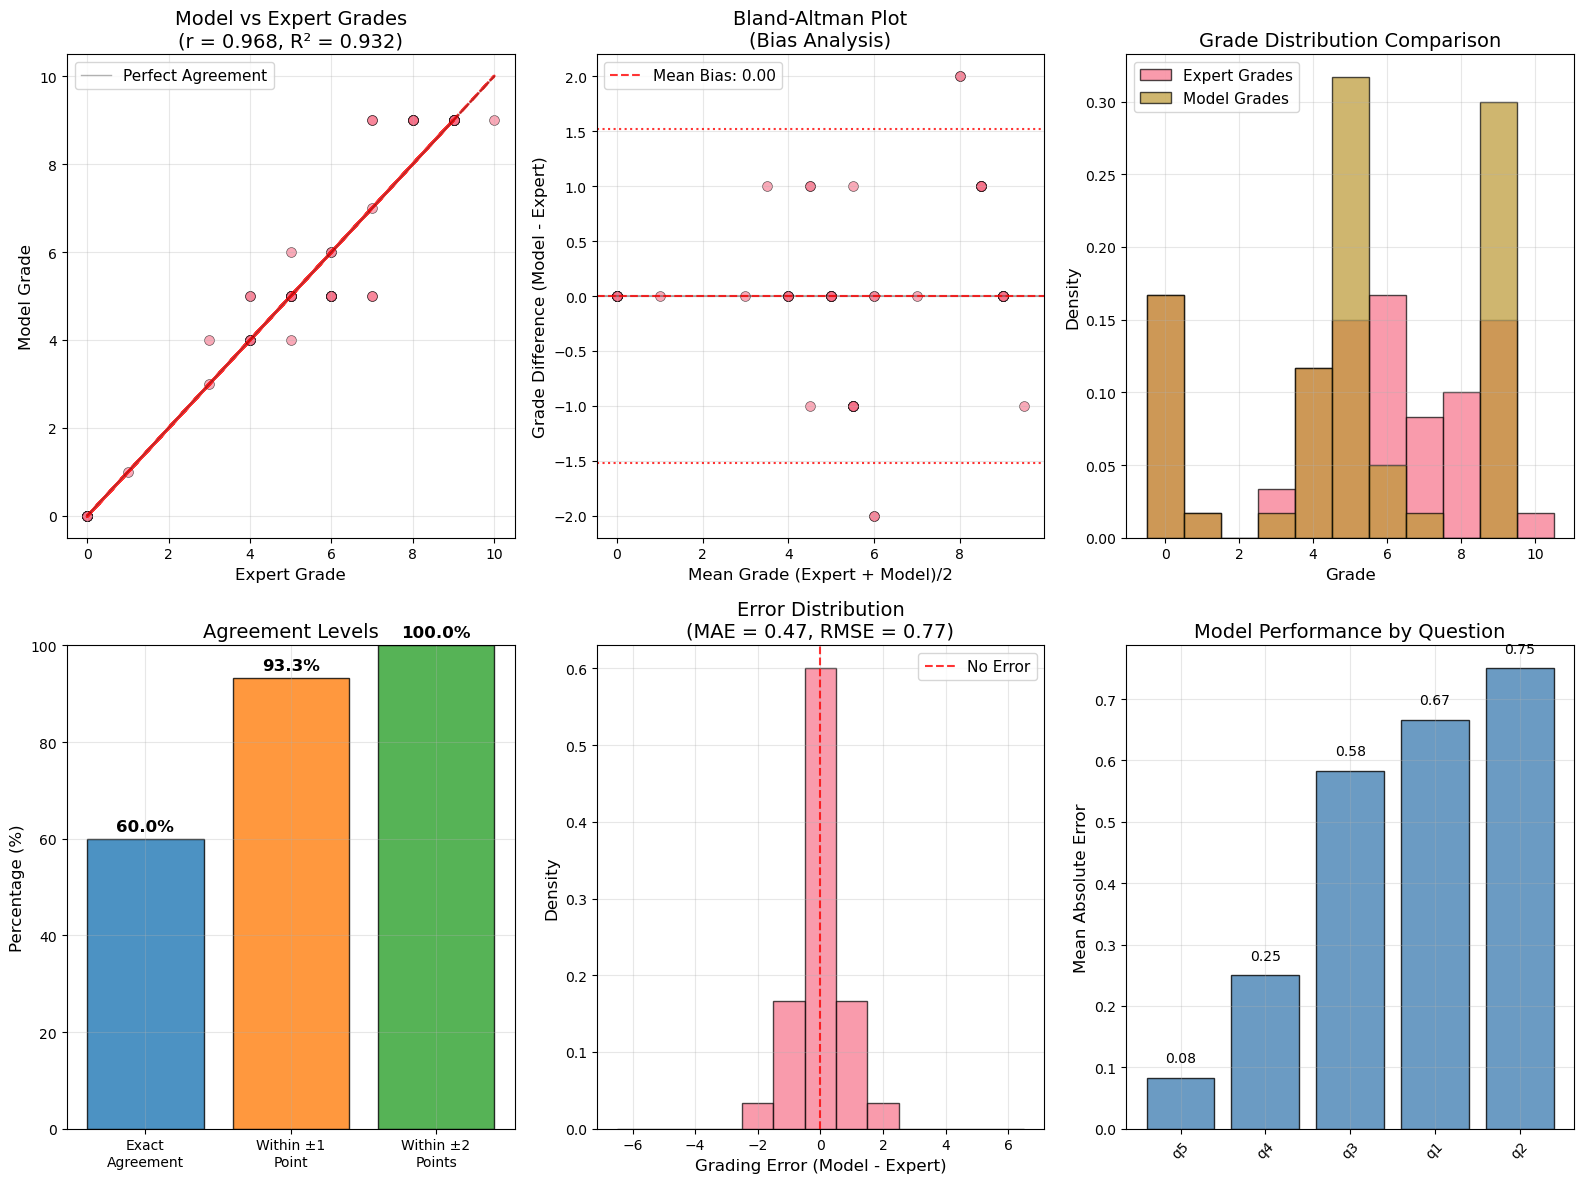

Creating confusion matrix...


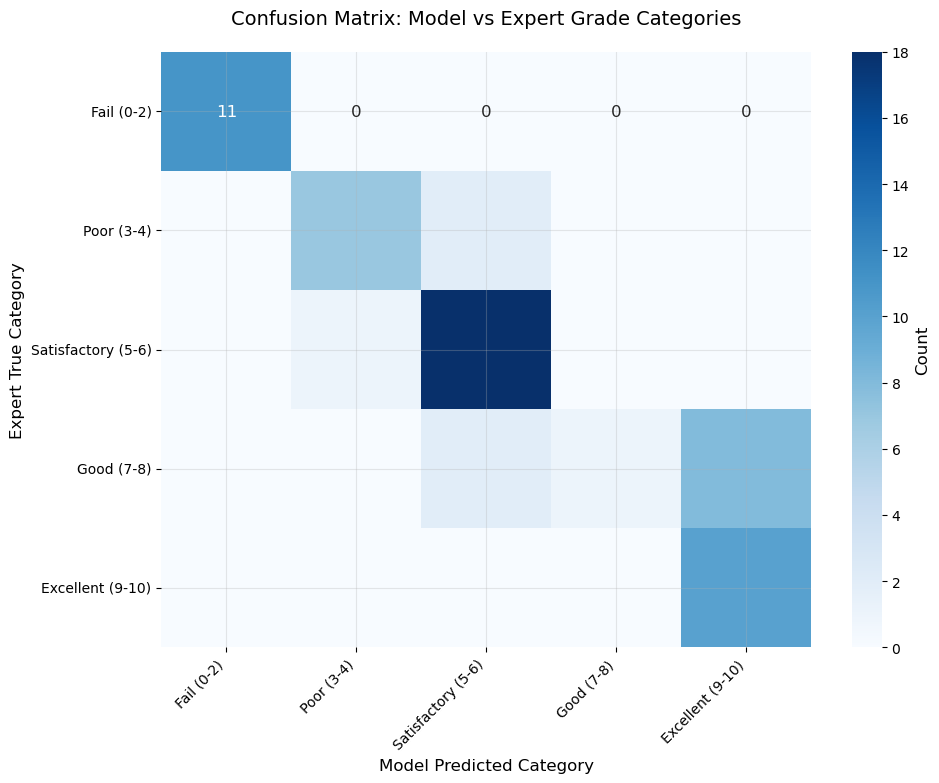


Analysis complete!
Figures saved to: results


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set academic style for plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.grid': True,
    'grid.alpha': 0.3
})

def load_data(json_file_path):
    """Load and parse the grading data from JSON file"""
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extract all grades into a structured format
    results = []
    for question_id, question_data in data.items():
        question_text = question_data['question']
        for student_answer in question_data['graded_answers']:
            results.append({
                'question_id': question_id,
                'question_text': question_text,
                'student_id': student_answer['student_id'],
                'model_grade': student_answer['model_grade'],
                'expert_grade': student_answer['expert_grade'],
                'answer': student_answer['answer']
            })
    
    return pd.DataFrame(results)

def calculate_metrics(df):
    """Calculate comprehensive evaluation metrics"""
    model_grades = df['model_grade'].values
    expert_grades = df['expert_grade'].values
    
    # Basic statistical metrics
    mae = mean_absolute_error(expert_grades, model_grades)
    mse = mean_squared_error(expert_grades, model_grades)
    rmse = np.sqrt(mse)
    r2 = r2_score(expert_grades, model_grades)
    
    # Correlation metrics
    pearson_corr, pearson_p = stats.pearsonr(model_grades, expert_grades)
    spearman_corr, spearman_p = stats.spearmanr(model_grades, expert_grades)
    
    # Agreement metrics
    exact_agreement = np.sum(model_grades == expert_grades) / len(model_grades)
    within_1_point = np.sum(np.abs(model_grades - expert_grades) <= 1) / len(model_grades)
    within_2_points = np.sum(np.abs(model_grades - expert_grades) <= 2) / len(model_grades)
    
    # Bias analysis
    mean_difference = np.mean(model_grades - expert_grades)
    std_difference = np.std(model_grades - expert_grades)
    
    # Classification accuracy (pass/fail at threshold 5)
    model_pass = model_grades >= 5
    expert_pass = expert_grades >= 5
    classification_accuracy = np.sum(model_pass == expert_pass) / len(model_grades)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'Pearson_r': pearson_corr,
        'Pearson_p': pearson_p,
        'Spearman_ρ': spearman_corr,
        'Spearman_p': spearman_p,
        'Exact_Agreement': exact_agreement,
        'Within_1_Point': within_1_point,
        'Within_2_Points': within_2_points,
        'Mean_Bias': mean_difference,
        'Std_Bias': std_difference,
        'Classification_Accuracy': classification_accuracy
    }

def create_academic_visualizations(df, metrics, save_path=''):
    """Create publication-ready visualizations"""
    
    # Set up the figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Scatter plot with regression line
    ax1 = plt.subplot(2, 3, 1)
    x = df['expert_grade']
    y = df['model_grade']
    
    # Scatter plot
    plt.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
    
    # Regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", alpha=0.8, linewidth=2)
    
    # Perfect agreement line
    plt.plot([0, 10], [0, 10], 'k-', alpha=0.3, linewidth=1, label='Perfect Agreement')
    
    plt.xlabel('Expert Grade')
    plt.ylabel('Model Grade')
    plt.title(f'Model vs Expert Grades\n(r = {metrics["Pearson_r"]:.3f}, R² = {metrics["R²"]:.3f})')
    plt.xlim(-0.5, 10.5)
    plt.ylim(-0.5, 10.5)
    plt.legend()
    
    # 2. Bland-Altman plot
    ax2 = plt.subplot(2, 3, 2)
    diff = y - x
    mean_grades = (x + y) / 2
    
    plt.scatter(mean_grades, diff, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axhline(y=np.mean(diff), color='r', linestyle='--', alpha=0.8, label=f'Mean Bias: {np.mean(diff):.2f}')
    plt.axhline(y=np.mean(diff) + 1.96*np.std(diff), color='r', linestyle=':', alpha=0.8)
    plt.axhline(y=np.mean(diff) - 1.96*np.std(diff), color='r', linestyle=':', alpha=0.8)
    
    plt.xlabel('Mean Grade (Expert + Model)/2')
    plt.ylabel('Grade Difference (Model - Expert)')
    plt.title('Bland-Altman Plot\n(Bias Analysis)')
    plt.legend()
    
    # 3. Distribution comparison
    ax3 = plt.subplot(2, 3, 3)
    bins = np.arange(-0.5, 11.5, 1)
    plt.hist(x, bins=bins, alpha=0.7, label='Expert Grades', density=True, edgecolor='black')
    plt.hist(y, bins=bins, alpha=0.7, label='Model Grades', density=True, edgecolor='black')
    plt.xlabel('Grade')
    plt.ylabel('Density')
    plt.title('Grade Distribution Comparison')
    plt.legend()
    
    # 4. Agreement analysis
    ax4 = plt.subplot(2, 3, 4)
    agreement_data = [
        metrics['Exact_Agreement'] * 100,
        metrics['Within_1_Point'] * 100,
        metrics['Within_2_Points'] * 100
    ]
    labels = ['Exact\nAgreement', 'Within ±1\nPoint', 'Within ±2\nPoints']
    bars = plt.bar(labels, agreement_data, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for bar, value in zip(bars, agreement_data):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.ylabel('Percentage (%)')
    plt.title('Agreement Levels')
    plt.ylim(0, 100)
    
    # 5. Error distribution
    ax5 = plt.subplot(2, 3, 5)
    errors = y - x
    plt.hist(errors, bins=np.arange(-6.5, 7.5, 1), alpha=0.7, edgecolor='black', density=True)
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.8, label='No Error')
    plt.xlabel('Grading Error (Model - Expert)')
    plt.ylabel('Density')
    plt.title(f'Error Distribution\n(MAE = {metrics["MAE"]:.2f}, RMSE = {metrics["RMSE"]:.2f})')
    plt.legend()
    
    # 6. Performance by question
    ax6 = plt.subplot(2, 3, 6)
    question_metrics = df.groupby('question_id').apply(
        lambda x: mean_absolute_error(x['expert_grade'], x['model_grade'])
    ).sort_values()
    
    bars = plt.bar(range(len(question_metrics)), question_metrics.values, 
                   color='steelblue', alpha=0.8, edgecolor='black')
    plt.xticks(range(len(question_metrics)), question_metrics.index, rotation=45)
    plt.ylabel('Mean Absolute Error')
    plt.title('Model Performance by Question')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, question_metrics.values)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{value:.2f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f'{save_path}/grading_analysis.png', dpi=300, bbox_inches='tight')
        plt.savefig(f'{save_path}/grading_analysis.pdf', bbox_inches='tight')
    
    plt.show()

def create_confusion_matrix(df, save_path=''):
    """Create confusion matrix for grade categories"""
    
    # Define grade categories
    def categorize_grade(grade):
        if grade >= 9:
            return 'Excellent (9-10)'
        elif grade >= 7:
            return 'Good (7-8)'
        elif grade >= 5:
            return 'Satisfactory (5-6)'
        elif grade >= 3:
            return 'Poor (3-4)'
        else:
            return 'Fail (0-2)'
    
    expert_categories = df['expert_grade'].apply(categorize_grade)
    model_categories = df['model_grade'].apply(categorize_grade)
    
    # Create confusion matrix
    categories = ['Fail (0-2)', 'Poor (3-4)', 'Satisfactory (5-6)', 'Good (7-8)', 'Excellent (9-10)']
    confusion_matrix = pd.crosstab(expert_categories, model_categories, margins=True)
    
    # Reorder to match categories
    confusion_matrix = confusion_matrix.reindex(categories + ['All'], columns=categories + ['All'])
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', 
                xticklabels=categories, yticklabels=categories, cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix: Model vs Expert Grade Categories', fontsize=14, pad=20)
    plt.xlabel('Model Predicted Category', fontsize=12)
    plt.ylabel('Expert True Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    if save_path:
        plt.savefig(f'{save_path}/confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.savefig(f'{save_path}/confusion_matrix.pdf', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    
    return confusion_matrix

def generate_academic_report(df, metrics):
    """Generate a comprehensive academic report"""
    
    print("="*80)
    print("AUTOMATED GRADING MODEL EVALUATION REPORT")
    print("="*80)
    print()
    
    # Dataset overview
    print("DATASET OVERVIEW")
    print("-" * 40)
    print(f"Total submissions: {len(df)}")
    print(f"Number of questions: {df['question_id'].nunique()}")
    print(f"Number of students: {df['student_id'].nunique()}")
    print(f"Expert grade range: {df['expert_grade'].min():.1f} - {df['expert_grade'].max():.1f}")
    print(f"Model grade range: {df['model_grade'].min():.1f} - {df['model_grade'].max():.1f}")
    print()
    
    # Statistical Performance
    print("STATISTICAL PERFORMANCE METRICS")
    print("-" * 40)
    print(f"Mean Absolute Error (MAE):     {metrics['MAE']:.3f}")
    print(f"Root Mean Square Error (RMSE): {metrics['RMSE']:.3f}")
    print(f"R-squared (R²):                {metrics['R²']:.3f}")
    print(f"Pearson Correlation:           {metrics['Pearson_r']:.3f} (p = {metrics['Pearson_p']:.3e})")
    print(f"Spearman Correlation:          {metrics['Spearman_ρ']:.3f} (p = {metrics['Spearman_p']:.3e})")
    print()
    
    # Agreement Analysis
    print("AGREEMENT ANALYSIS")
    print("-" * 40)
    print(f"Exact Agreement:               {metrics['Exact_Agreement']:.1%}")
    print(f"Agreement within ±1 point:     {metrics['Within_1_Point']:.1%}")
    print(f"Agreement within ±2 points:    {metrics['Within_2_Points']:.1%}")
    print(f"Classification Accuracy:       {metrics['Classification_Accuracy']:.1%}")
    print()
    
    # Bias Analysis
    print("BIAS ANALYSIS")
    print("-" * 40)
    print(f"Mean Bias (Model - Expert):    {metrics['Mean_Bias']:+.3f}")
    print(f"Standard Deviation of Bias:    {metrics['Std_Bias']:.3f}")
    if abs(metrics['Mean_Bias']) < 0.1:
        bias_interpretation = "negligible"
    elif abs(metrics['Mean_Bias']) < 0.5:
        bias_interpretation = "small"
    elif abs(metrics['Mean_Bias']) < 1.0:
        bias_interpretation = "moderate"
    else:
        bias_interpretation = "large"
    
    direction = "overestimation" if metrics['Mean_Bias'] > 0 else "underestimation"
    print(f"Bias Interpretation:           {bias_interpretation} {direction}")
    print()
    
    # Performance by Question
    print("PERFORMANCE BY QUESTION")
    print("-" * 40)
    question_analysis = df.groupby('question_id').agg({
        'expert_grade': ['mean', 'std'],
        'model_grade': ['mean', 'std']
    }).round(2)
    
    question_mae = df.groupby('question_id').apply(
        lambda x: mean_absolute_error(x['expert_grade'], x['model_grade'])
    ).round(3)
    
    for q_id in df['question_id'].unique():
        expert_mean = question_analysis.loc[q_id, ('expert_grade', 'mean')]
        model_mean = question_analysis.loc[q_id, ('model_grade', 'mean')]
        mae = question_mae[q_id]
        print(f"{q_id}: Expert μ={expert_mean:.1f}, Model μ={model_mean:.1f}, MAE={mae:.3f}")
    print()
    
    # Statistical Significance Tests
    print("STATISTICAL SIGNIFICANCE TESTS")
    print("-" * 40)
    
    # Paired t-test
    t_stat, t_p = stats.ttest_rel(df['model_grade'], df['expert_grade'])
    print(f"Paired t-test:                 t = {t_stat:.3f}, p = {t_p:.3e}")
    
    # Wilcoxon signed-rank test
    w_stat, w_p = stats.wilcoxon(df['model_grade'], df['expert_grade'])
    print(f"Wilcoxon signed-rank test:     W = {w_stat:.0f}, p = {w_p:.3e}")
    print()
    
    # Interpretation
    print("INTERPRETATION AND RECOMMENDATIONS")
    print("-" * 40)
    
    if metrics['Pearson_r'] > 0.9:
        corr_interpretation = "excellent"
    elif metrics['Pearson_r'] > 0.8:
        corr_interpretation = "very good"
    elif metrics['Pearson_r'] > 0.7:
        corr_interpretation = "good"
    elif metrics['Pearson_r'] > 0.5:
        corr_interpretation = "moderate"
    else:
        corr_interpretation = "poor"
    
    print(f"• Correlation strength: {corr_interpretation} (r = {metrics['Pearson_r']:.3f})")
    print(f"• Agreement level: {metrics['Within_1_Point']:.0%} within ±1 point")
    print(f"• Model reliability: {'High' if metrics['RMSE'] < 1.0 else 'Moderate' if metrics['RMSE'] < 2.0 else 'Low'}")
    
    if metrics['Pearson_p'] < 0.001:
        print("• Statistical significance: Highly significant (p < 0.001)")
    elif metrics['Pearson_p'] < 0.01:
        print("• Statistical significance: Very significant (p < 0.01)")
    elif metrics['Pearson_p'] < 0.05:
        print("• Statistical significance: Significant (p < 0.05)")
    else:
        print("• Statistical significance: Not significant (p ≥ 0.05)")
    
    print()
    print("="*80)

def main(json_file_path, save_path=''):
    """Main analysis function"""
    
    # Load data
    print("Loading data...")
    df = load_data(json_file_path)
    
    # Calculate metrics
    print("Calculating metrics...")
    metrics = calculate_metrics(df)
    
    # Generate report
    generate_academic_report(df, metrics)
    
    # Create visualizations
    print("Creating visualizations...")
    create_academic_visualizations(df, metrics, save_path)
    
    # Create confusion matrix
    print("Creating confusion matrix...")
    confusion_matrix = create_confusion_matrix(df, save_path)
    
    return df, metrics, confusion_matrix

# Example usage:
if __name__ == "__main__":
    # Replace 'your_data.json' with the actual path to your JSON file
    json_file_path = 'graded_results.json'
    save_path = 'results'  # Directory to save figures
    
    # Run the complete analysis
    df, metrics, confusion_matrix = main(json_file_path, save_path)
    
    # Additional analysis can be added here
    print("\nAnalysis complete!")
    print("Figures saved to:", save_path)